# Linear Regression: 預測用餐時間 (Reservation Seconds)

目標：以 `reservation_seconds`（當天 00:00 起算的秒數，0-86399）為預測目標，使用 Linear Regression 了解資料表現與各特徵重要性。

**Preprocessing 流程**：`features_ready.csv` → 填補缺失值 → Drop leakage 欄位 → Train/Test Split → One-Hot Encoding → StandardScaler

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from src.preprocessing.common import load_features, split_data, fill_missing
from src.preprocessing.regression import preprocess_for_regression

sns.set_theme(style="whitegrid")
plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False

In [2]:
# --- Cell 2: Data Loading & Overview ---
df = load_features("../data/processed/features_ready.csv")

print(f"Shape: {df.shape}")
print(f"\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\n--- Data Types ---")
print(df.dtypes)
df.head(3)

Shape: (116972, 33)

--- Missing Values ---
hotel_restaurant         13345
city_code                13345
city_area_code           13345
family_friendly          13345
accepts_credit_card      13345
has_parking              13345
outdoor_seating          13345
has_wifi                 13345
wheelchair_accessible    13345
lat                      13345
lng                      13345
is_vip_member             9099
account_gender            9099
member_birthdate         42808
member_city_code          9099
age                      42808
avg_price                13345
dtype: int64

--- Data Types ---
booking_time              object
reservation_time          object
party_size                 int64
dining_purpose            object
booked_by_gender          object
prepay_satisfied           int64
hotel_restaurant         float64
city_code                 object
city_area_code            object
family_friendly          float64
accepts_credit_card      float64
has_parking              float64


d:\Taiwei\RestaurantBookings\notebooks\..\src\preprocessing\common.py:18: DtypeWarning: Columns (18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


,booking_time,reservation_time,party_size,dining_purpose,booked_by_gender,prepay_satisfied,hotel_restaurant,city_code,city_area_code,family_friendly,...,booking_hour,reservation_hour,reservation_seconds,weekday,avg_price,is_holiday_vicinity,days_from_payday,popular_hour,dinner_ratio,restaurant_density
0,2014-07-06 16:11:00,2014-07-07 18:30:00,6,生日慶祝,M,1,1.0,台中市,Unknown,1.0,...,16,18,66600,1,465.0,0,2.0,11,0.375000,457
1,2014-07-06 18:01:00,2014-07-21 19:00:00,8,生日慶祝,F,1,1.0,台北市,中正區,1.0,...,18,19,68400,1,844.5,0,15.0,15,0.351641,14
2,2014-07-07 00:53:00,2014-07-27 14:20:00,4,生日慶祝,F,1,1.0,高雄市,Unknown,1.0,...,0,14,51600,7,683.5,0,9.0,19,0.459459,457


In [3]:
df.shape

(116972, 33)

In [4]:
df2 = df.copy()
df = df.dropna()
df.shape

(66349, 33)

In [5]:
print(f"Shape: {df.shape}")
print(f"\n--- Missing Values ---")
missing = df.isnull().sum()
print(missing[missing > 0])
print(f"\n--- Data Types ---")
print(df.dtypes)
df.head(3)

Shape: (66349, 33)

--- Missing Values ---
Series([], dtype: int64)

--- Data Types ---
booking_time              object
reservation_time          object
party_size                 int64
dining_purpose            object
booked_by_gender          object
prepay_satisfied           int64
hotel_restaurant         float64
city_code                 object
city_area_code            object
family_friendly          float64
accepts_credit_card      float64
has_parking              float64
outdoor_seating          float64
has_wifi                 float64
wheelchair_accessible    float64
lat                      float64
lng                      float64
is_vip_member            float64
account_gender            object
member_birthdate          object
member_city_code          object
lead_time                float64
age                      float64
booking_hour               int64
reservation_hour           int64
reservation_seconds        int64
weekday                    int64
avg_price            

,booking_time,reservation_time,party_size,dining_purpose,booked_by_gender,prepay_satisfied,hotel_restaurant,city_code,city_area_code,family_friendly,...,booking_hour,reservation_hour,reservation_seconds,weekday,avg_price,is_holiday_vicinity,days_from_payday,popular_hour,dinner_ratio,restaurant_density
1,2014-07-06 18:01:00,2014-07-21 19:00:00,8,生日慶祝,F,1,1.0,台北市,中正區,1.0,...,18,19,68400,1,844.5,0,15.0,15,0.351641,14
2,2014-07-07 00:53:00,2014-07-27 14:20:00,4,生日慶祝,F,1,1.0,高雄市,Unknown,1.0,...,0,14,51600,7,683.5,0,9.0,19,0.459459,457
3,2014-09-01 01:42:00,2014-09-19 18:00:00,2,Unknown,F,1,0.0,台北市,信義區,1.0,...,1,18,64800,5,1793.0,0,14.0,18,0.619546,14


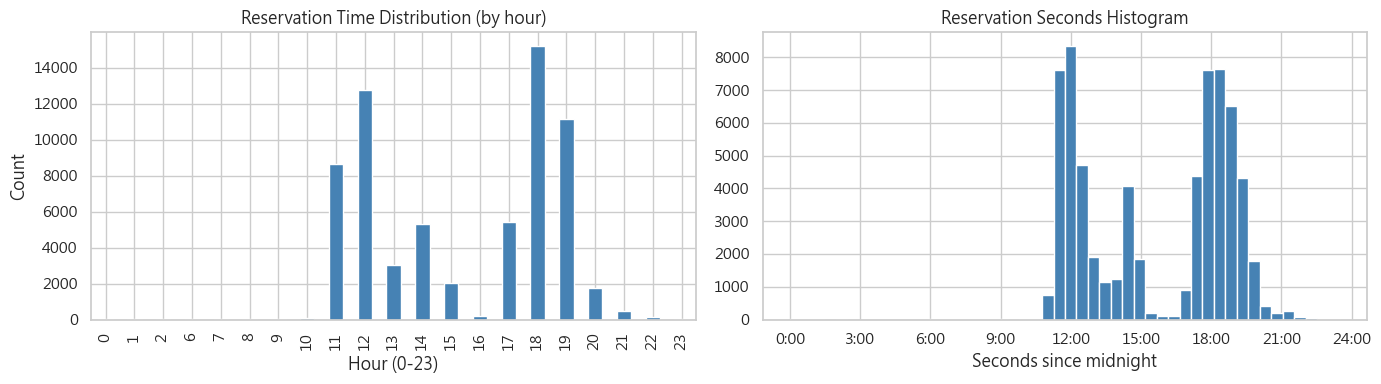

count    66349.000000
mean     56550.802574
std      11385.248377
min          0.000000
25%      43200.000000
50%      62100.000000
75%      66600.000000
max      84600.000000
Name: reservation_seconds, dtype: float64


In [6]:
# --- Cell 3: Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart by hour bucket
hour_buckets = (df["reservation_seconds"] // 3600).astype(int)
hour_buckets.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Reservation Time Distribution (by hour)")
axes[0].set_xlabel("Hour (0-23)")
axes[0].set_ylabel("Count")

# Histogram in seconds
axes[1].hist(df["reservation_seconds"], bins=48, color="steelblue", edgecolor="white")
axes[1].set_title("Reservation Seconds Histogram")
axes[1].set_xlabel("Seconds since midnight")
sec_ticks = [h * 3600 for h in range(0, 25, 3)]
axes[1].set_xticks(sec_ticks)
axes[1].set_xticklabels([f"{h}:00" for h in range(0, 25, 3)])

plt.tight_layout()
plt.show()

print(df["reservation_seconds"].describe())

In [7]:
# --- Cell 4: Preprocessing ---
TARGET = "reservation_seconds"
LEAKAGE_COLS = ["reservation_hour"]  # derived from same datetime as target

#df_clean = fill_missing(df)
df_clean = df.drop(columns=LEAKAGE_COLS)

X_train, X_test, y_train, y_test = split_data(df_clean, target_col=TARGET)
X_train_proc, X_test_proc, scaler = preprocess_for_regression(X_train, X_test)

print(f"Dropped leakage columns: {LEAKAGE_COLS}")
print(f"Train: {X_train_proc.shape}, Test: {X_test_proc.shape}")
print(f"Features after one-hot encoding: {X_train_proc.shape[1]}")

Dropped leakage columns: ['reservation_hour']
Train: (53079, 154), Test: (13270, 154)
Features after one-hot encoding: 154


In [8]:
# --- Cell 5: Model Training ---
model = LinearRegression()
model.fit(X_train_proc, y_train)

y_pred = model.predict(X_test_proc)
print("Model training completed.")

Model training completed.


In [9]:
# --- Cell 6: Evaluation Metrics ---
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=== Linear Regression Performance ===")
print(f"RMSE : {rmse:.0f} sec ({rmse/60:.1f} min)")
print(f"MAE  : {mae:.0f} sec ({mae/60:.1f} min)")
print(f"R²   : {r2:.4f}")
print(f"\nInterpretation: 平均預測誤差約 {mae/60:.0f} 分鐘")

=== Linear Regression Performance ===
RMSE : 10669 sec (177.8 min)
MAE  : 9591 sec (159.8 min)
R²   : 0.1167

Interpretation: 平均預測誤差約 160 分鐘


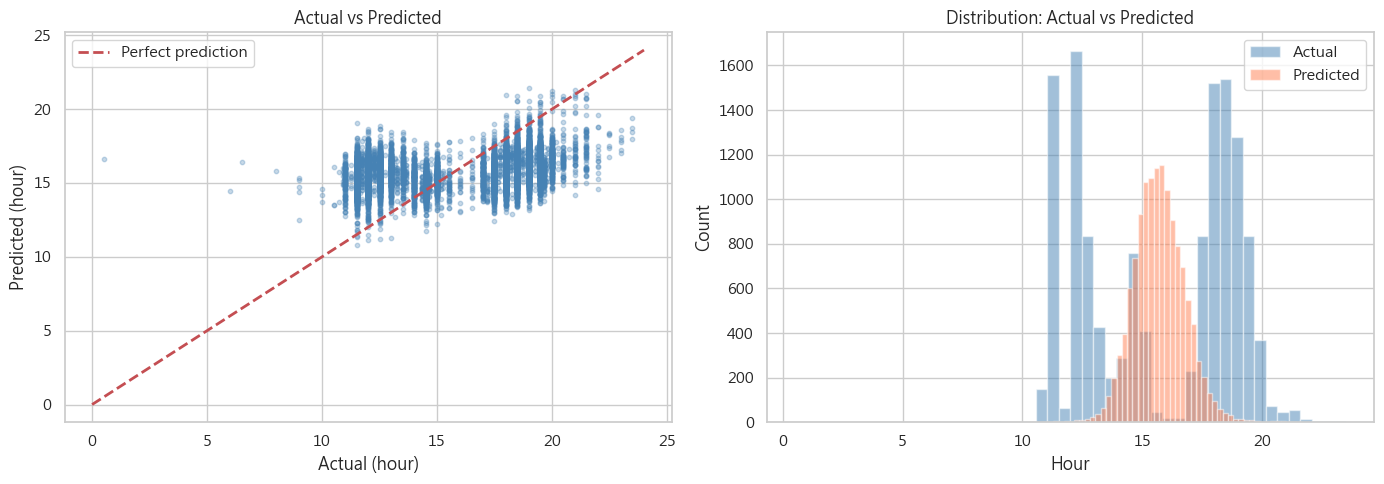

In [12]:
# --- Cell 7: Actual vs Predicted ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot (axis in hours for readability)
axes[0].scatter(y_test / 3600, y_pred / 3600, alpha=0.3, s=10, color="steelblue")
axes[0].plot([0, 24], [0, 24], "r--", linewidth=2, label="Perfect prediction")
axes[0].set_xlabel("Actual (hour)")
axes[0].set_ylabel("Predicted (hour)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

# Distribution comparison
axes[1].hist(y_test / 3600, bins=48, alpha=0.5, label="Actual", color="steelblue", edgecolor="white")
axes[1].hist(y_pred / 3600, bins=48, alpha=0.5, label="Predicted", color="coral", edgecolor="white")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution: Actual vs Predicted")
axes[1].legend()

plt.tight_layout()
plt.show()

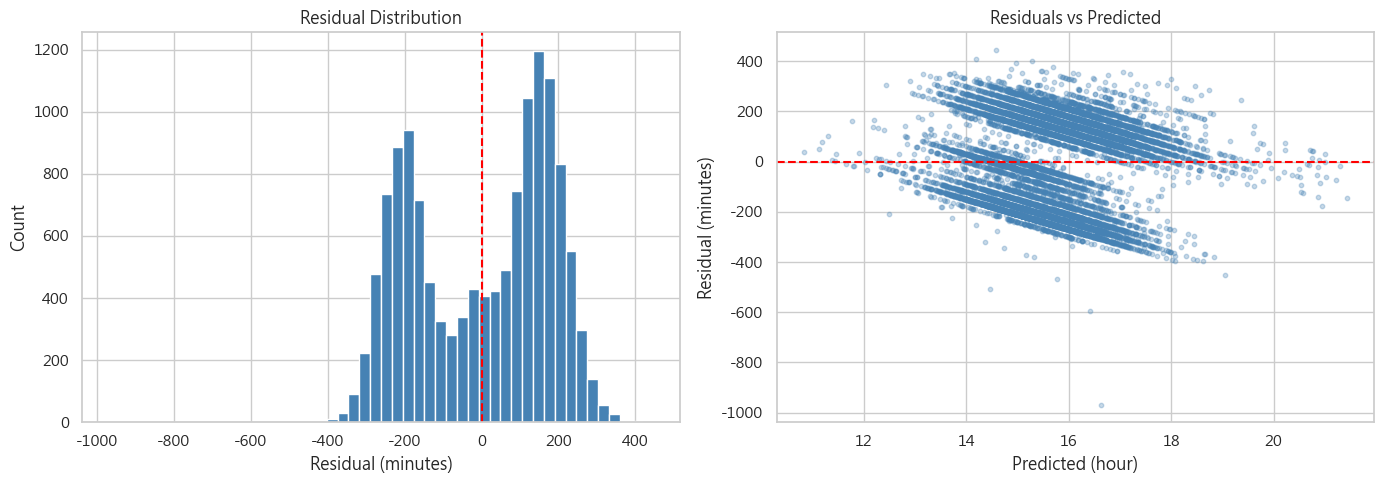

Residual mean: -0.0 min
Residual std:  177.8 min


In [13]:
# --- Cell 8: Residual Analysis ---
residuals_min = (y_test - y_pred) / 60  # convert to minutes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_min, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_xlabel("Residual (minutes)")
axes[0].set_ylabel("Count")
axes[0].set_title("Residual Distribution")

axes[1].scatter(y_pred / 3600, residuals_min, alpha=0.3, s=10, color="steelblue")
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted (hour)")
axes[1].set_ylabel("Residual (minutes)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals_min.mean():.1f} min")
print(f"Residual std:  {residuals_min.std():.1f} min")

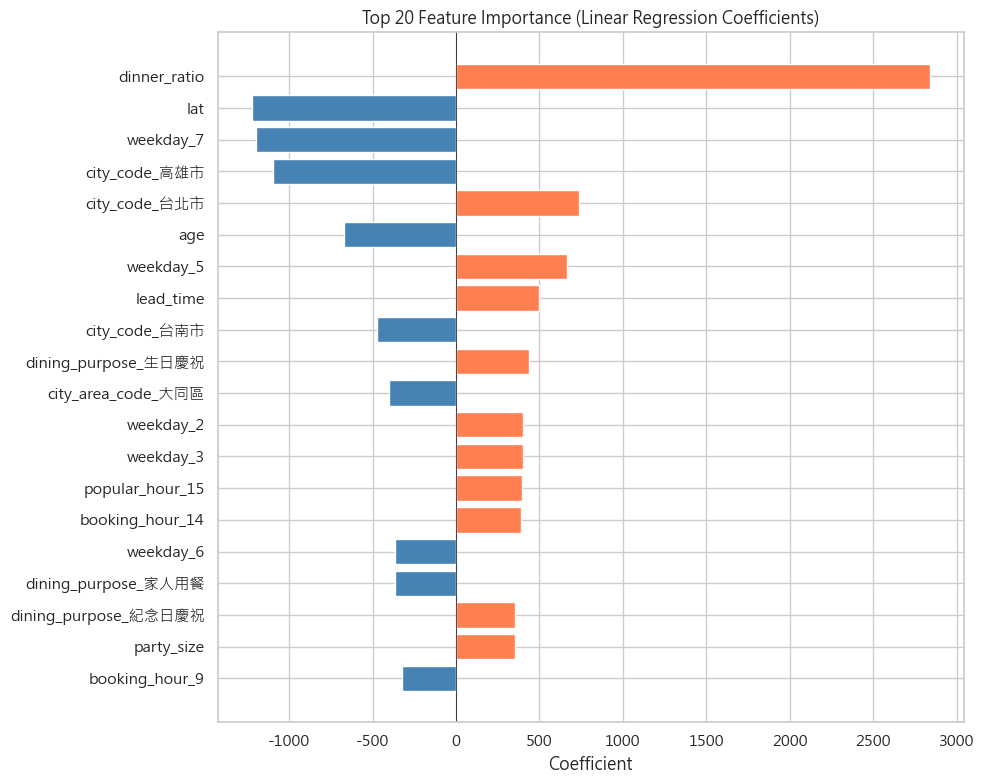


--- All coefficients ---


,feature,coefficient
0,dinner_ratio,2839.049640
1,lat,-1223.074358
2,weekday_7,-1200.022312
3,city_code_高雄市,-1093.319453
4,city_code_台北市,735.763343
...,...,...
149,member_city_code_上海市,5.933355
150,member_city_code_台中市,-5.535425
151,booking_hour_19,5.098184
152,popular_hour_19,-2.433878


In [14]:
# --- Cell 9: Feature Importance (Top 20) ---
coef_df = pd.DataFrame({
    "feature": X_train_proc.columns,
    "coefficient": model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

top_n = 20
top_features = coef_df.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["coral" if c > 0 else "steelblue" for c in top_features["coefficient"]]
ax.barh(range(len(top_features)), top_features["coefficient"], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features["feature"])
ax.invert_yaxis()
ax.set_xlabel("Coefficient")
ax.set_title(f"Top {top_n} Feature Importance (Linear Regression Coefficients)")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()
plt.show()

print(f"\n--- All coefficients ---")
display(coef_df.reset_index(drop=True))

## Summary

### Metrics
| Metric | Description |
|--------|-------------|
| RMSE   | 預測值與實際值的均方根誤差（秒/分鐘）|
| MAE    | 平均絕對誤差（秒/分鐘）|
| R²     | 模型解釋變異的比例（越接近 1 越好）|


從結果來看，我根本就不應該把午餐、下午茶跟晚餐的人放在同一個資料。他們各組應該是不同的客群才對。

In [15]:
# --- Split data by meal time ---
df_lunch = df[df["reservation_hour"].between(10, 14)]
df_afternoon = df[df["reservation_hour"].between(14, 17)]
df_dinner = df[df["reservation_hour"].between(17, 23)]

print(f"午餐 Lunch      (10-14h): {len(df_lunch):>6,} rows")
print(f"下午茶 Afternoon (14-17h): {len(df_afternoon):>6,} rows")
print(f"晚餐 Dinner     (17-23h): {len(df_dinner):>6,} rows")
print(f"其他 Other      ( 0-10h): {len(df) - len(df_lunch) - len(df_afternoon) - len(df_dinner):>6,} rows")
print(f"{'─'*42}")
print(f"Total                   : {len(df):>6,} rows")

午餐 Lunch      (10-14h): 29,850 rows
下午茶 Afternoon (14-17h): 12,985 rows
晚餐 Dinner     (17-23h): 34,198 rows
其他 Other      ( 0-10h): -10,684 rows
──────────────────────────────────────────
Total                   : 66,349 rows


## Sub-Dataset Analysis: 午餐 / 下午茶 / 晚餐

將資料依 `reservation_hour` 拆分為三個子資料集，分別建立獨立的 Linear Regression 模型，重複相同的分析流程：
- Preprocessing (drop leakage, split, one-hot, scale)
- Model training & metrics (RMSE, MAE, R²)
- Actual vs Predicted / Residual / Feature Importance

| Subset | reservation_hour |
|--------|-----------------|
| 午餐 Lunch | 10 - 14 |
| 下午茶 Afternoon Tea | 14 - 17 |
| 晚餐 Dinner | 17 - 23 |

In [19]:
def run_subset_analysis(df_subset, label):
    """對子資料集執行完整的 Linear Regression 分析。"""
    TARGET = "reservation_seconds"
    LEAKAGE_COLS = ["reservation_hour"]

    df_clean = df_subset.drop(columns=LEAKAGE_COLS, errors="ignore")
    X_tr, X_te, y_tr, y_te = split_data(df_clean, target_col=TARGET)
    X_tr_proc, X_te_proc, _ = preprocess_for_regression(X_tr, X_te)

    # Train
    mdl = LinearRegression()
    mdl.fit(X_tr_proc, y_tr)
    y_pr = mdl.predict(X_te_proc)

    # Metrics
    rmse = np.sqrt(mean_squared_error(y_te, y_pr))
    mae  = mean_absolute_error(y_te, y_pr)
    r2   = r2_score(y_te, y_pr)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Samples : {len(df_subset):,}  (Train {len(X_tr):,} / Test {len(X_te):,})")
    print(f"  Features: {X_tr_proc.shape[1]}")
    print(f"  RMSE : {rmse:,.0f} sec  ({rmse/60:.1f} min)")
    print(f"  MAE  : {mae:,.0f} sec  ({mae/60:.1f} min)")
    print(f"  R²   : {r2:.4f}")

    # --- 2x3 plot grid ---
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"{label} — Linear Regression", fontsize=14, fontweight="bold")

    # (0,0) Actual vs Predicted
    axes[0, 0].scatter(y_te / 3600, y_pr / 3600, alpha=0.3, s=10, color="steelblue")
    lo, hi = y_te.min() / 3600, y_te.max() / 3600
    axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect")
    axes[0, 0].set_xlabel("Actual (hour)")
    axes[0, 0].set_ylabel("Predicted (hour)")
    axes[0, 0].set_title("Actual vs Predicted")
    axes[0, 0].legend()

    # (0,1) Distribution comparison
    axes[0, 1].hist(y_te / 3600, bins=30, alpha=0.5, label="Actual", color="steelblue", edgecolor="white")
    axes[0, 1].hist(y_pr / 3600, bins=30, alpha=0.5, label="Predicted", color="coral", edgecolor="white")
    axes[0, 1].set_xlabel("Hour")
    axes[0, 1].set_title("Actual vs Predicted Distribution")
    axes[0, 1].legend()

    # (0,2) Target distribution
    hour_buckets = (df_subset["reservation_seconds"] // 3600).astype(int)
    hour_buckets.value_counts().sort_index().plot(kind="bar", ax=axes[0, 2], color="steelblue")
    axes[0, 2].set_title("Target Distribution (by hour)")
    axes[0, 2].set_xlabel("Hour")
    axes[0, 2].set_ylabel("Count")

    # (1,0) Residual distribution
    residuals_min = (y_te - y_pr) / 60
    axes[1, 0].hist(residuals_min, bins=40, color="steelblue", edgecolor="white")
    axes[1, 0].axvline(0, color="red", linestyle="--")
    axes[1, 0].set_xlabel("Residual (min)")
    axes[1, 0].set_title("Residual Distribution")

    # (1,1) Residuals vs Predicted
    axes[1, 1].scatter(y_pr / 3600, residuals_min, alpha=0.3, s=10, color="steelblue")
    axes[1, 1].axhline(0, color="red", linestyle="--")
    axes[1, 1].set_xlabel("Predicted (hour)")
    axes[1, 1].set_ylabel("Residual (min)")
    axes[1, 1].set_title("Residuals vs Predicted")

    # (1,2) Feature importance top 15
    coef_df = pd.DataFrame({
        "feature": X_tr_proc.columns,
        "coefficient": mdl.coef_
    }).sort_values("coefficient", key=abs, ascending=False)
    top = coef_df.head(15)
    bar_colors = ["coral" if c > 0 else "steelblue" for c in top["coefficient"]]
    axes[1, 2].barh(range(len(top)), top["coefficient"], color=bar_colors)
    axes[1, 2].set_yticks(range(len(top)))
    axes[1, 2].set_yticklabels(top["feature"], fontsize=8)
    axes[1, 2].invert_yaxis()
    axes[1, 2].set_xlabel("Coefficient")
    axes[1, 2].set_title("Top 15 Features")
    axes[1, 2].axvline(0, color="black", linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return {"label": label, "n": len(df_subset), "rmse_sec": rmse, "mae_sec": mae, "r2": r2}

print("run_subset_analysis() defined.")

run_subset_analysis() defined.



  午餐 Lunch (10-14h)
  Samples : 29,850  (Train 23,880 / Test 5,970)
  Features: 151
  RMSE : 3,472 sec  (57.9 min)
  MAE  : 2,833 sec  (47.2 min)
  R²   : 0.1476


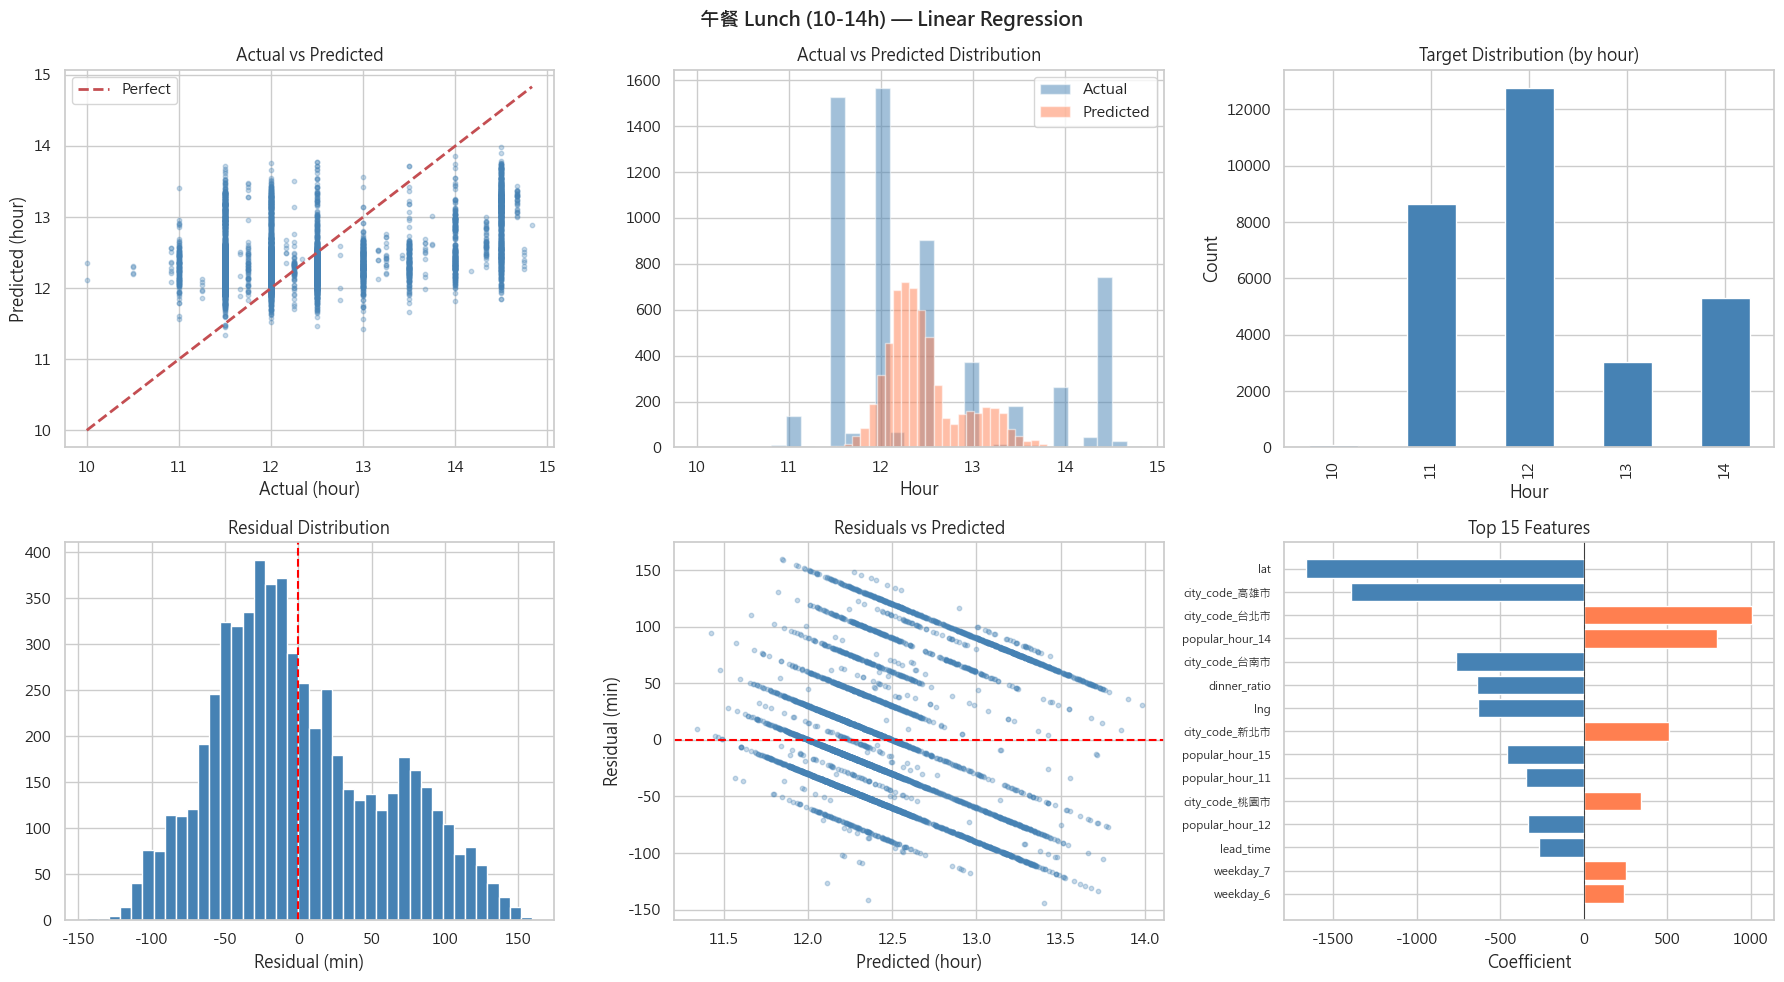


  下午茶 Afternoon (14-17h)
  Samples : 12,985  (Train 10,388 / Test 2,597)
  Features: 148
  RMSE : 4,332 sec  (72.2 min)
  MAE  : 3,554 sec  (59.2 min)
  R²   : 0.2923


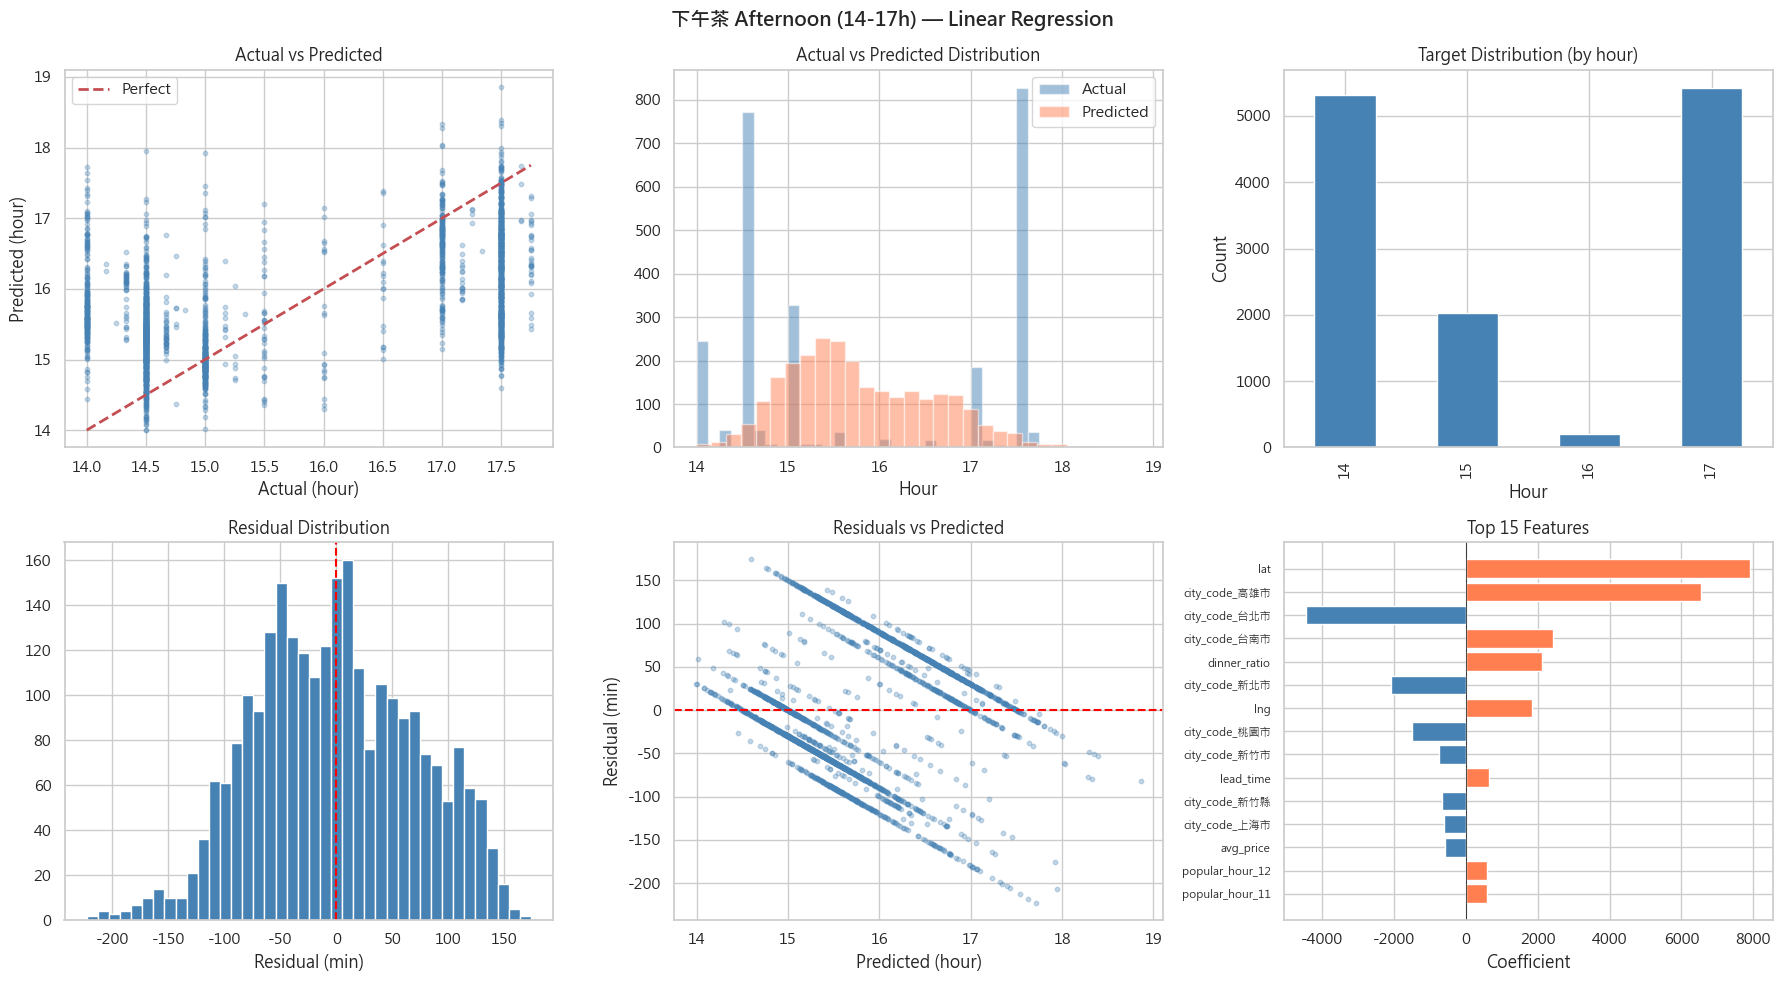


  晚餐 Dinner (17-23h)
  Samples : 34,198  (Train 27,358 / Test 6,840)
  Features: 153
  RMSE : 2,846 sec  (47.4 min)
  MAE  : 2,192 sec  (36.5 min)
  R²   : 0.1652


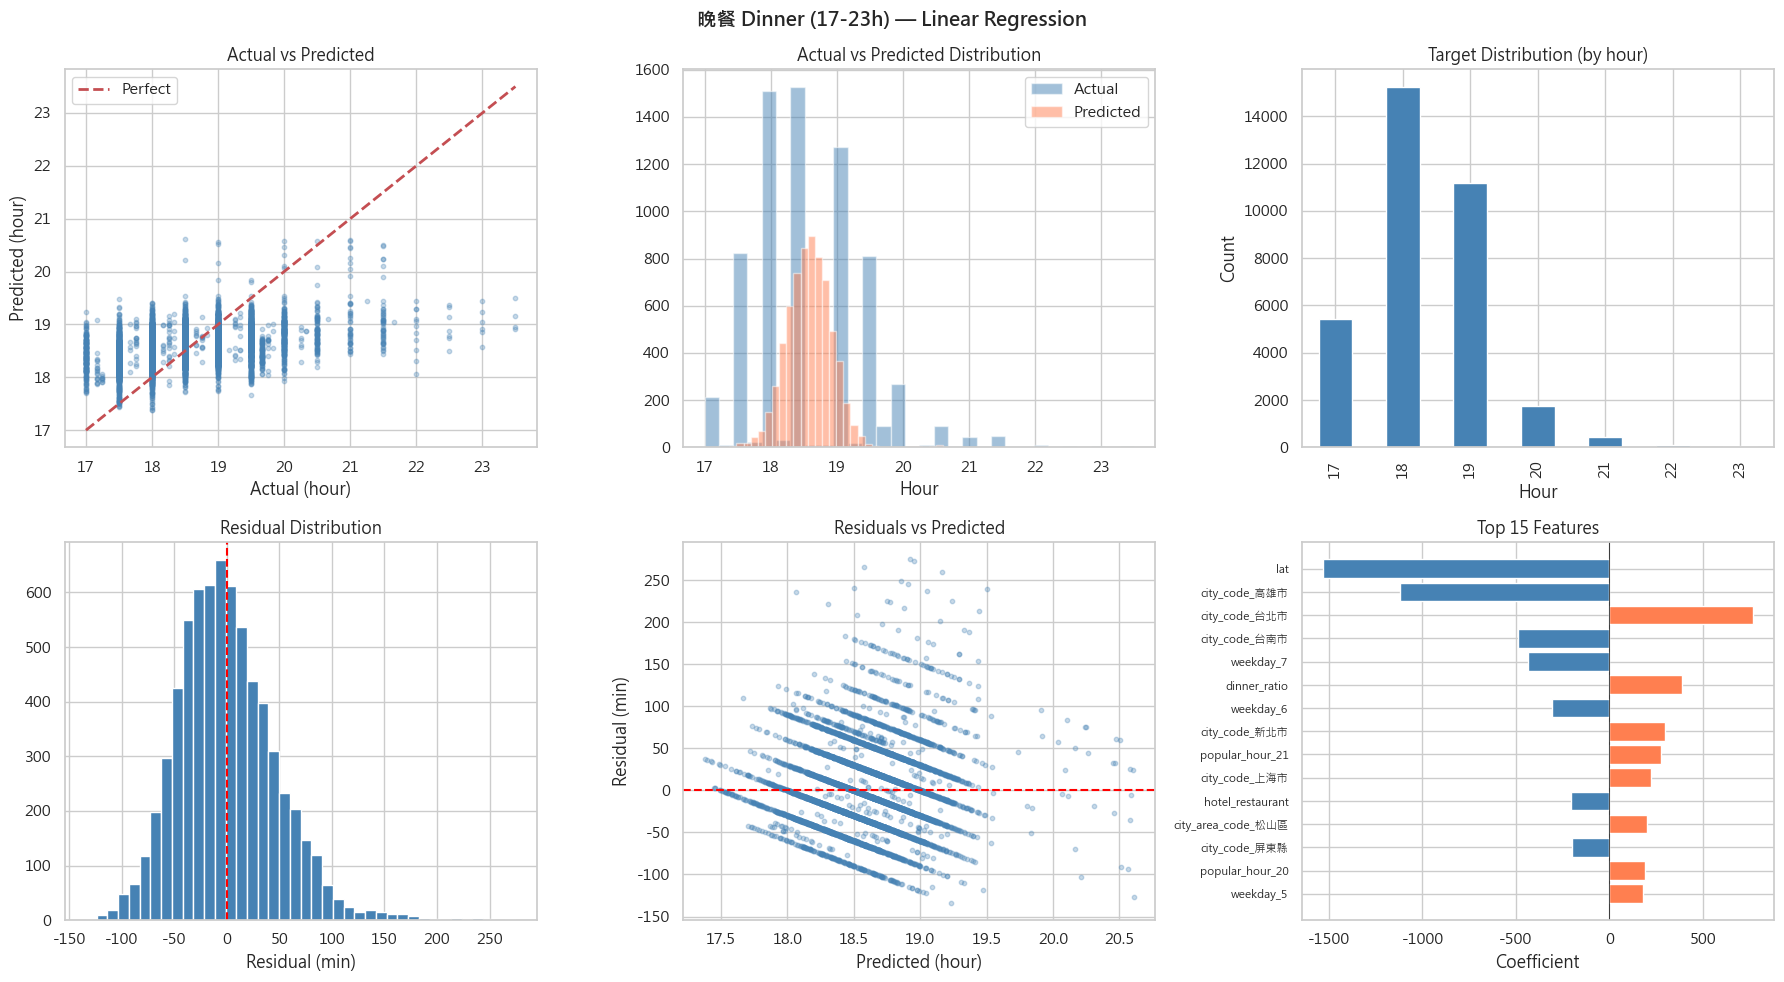

In [20]:
# --- Run analysis on each subset ---
results = []
for subset, label in [
    (df_lunch,     "午餐 Lunch (10-14h)"),
    (df_afternoon, "下午茶 Afternoon (14-17h)"),
    (df_dinner,    "晚餐 Dinner (17-23h)"),
]:
    results.append(run_subset_analysis(subset, label))

  COMPARISON SUMMARY (vs Full Dataset)


'                Subset  Samples  RMSE (min)  MAE (min)       R²\n       全部 Full Dataset    66349  177.808735 159.843132 0.116691\n     午餐 Lunch (11-14h)    29850   57.870394  47.224885 0.147554\n下午茶 Afternoon (15-17h)    12985   72.201806  59.240589 0.292288\n    晚餐 Dinner (18-23h)    34198   47.429102  36.530147 0.165220'

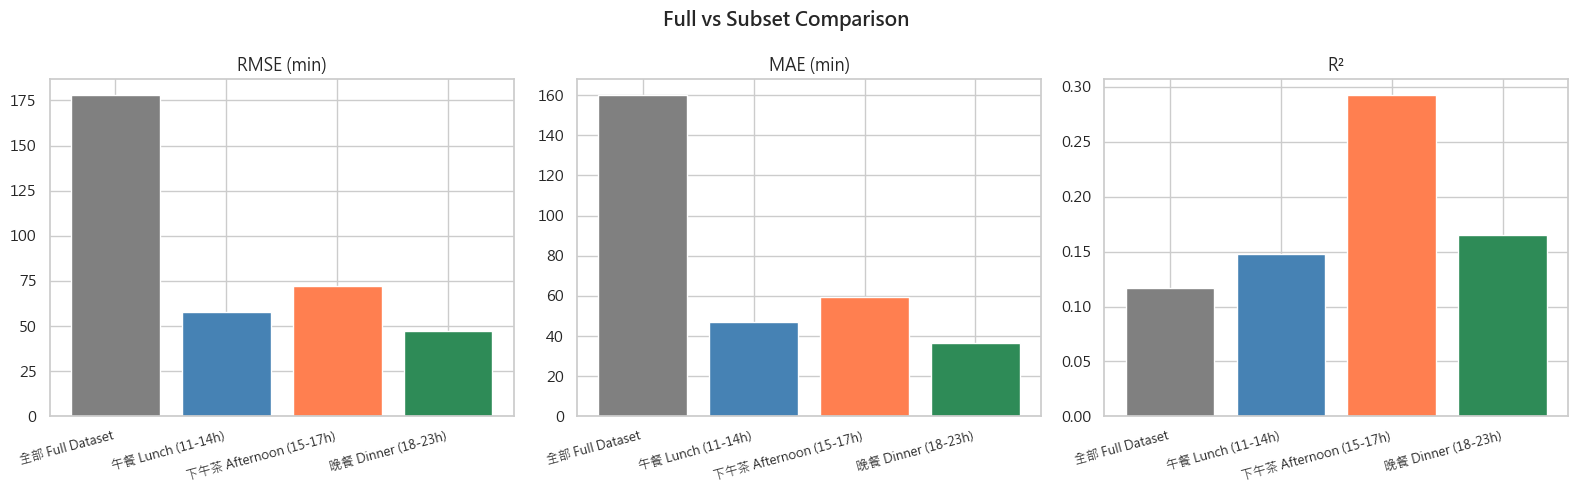

In [18]:
# ============================================================
#  Comparison Summary
# ============================================================
print("="*70)
print("  COMPARISON SUMMARY (vs Full Dataset)")
print("="*70)

# Add full-dataset result for comparison
full_result = {
    "label": f"全部 Full Dataset",
    "n": len(df),
    "rmse_sec": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae_sec": mean_absolute_error(y_test, y_pred),
    "r2": r2_score(y_test, y_pred),
}
all_results = [full_result] + results

comp_df = pd.DataFrame(all_results)
comp_df["RMSE (min)"] = comp_df["rmse_sec"] / 60
comp_df["MAE (min)"]  = comp_df["mae_sec"] / 60
display(comp_df[["label", "n", "RMSE (min)", "MAE (min)", "r2"]].rename(columns={
    "label": "Subset", "n": "Samples", "r2": "R²"
}).to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_short = [r["label"] for r in all_results]
colors = ["gray", "steelblue", "coral", "seagreen"]
x = range(len(labels_short))

for ax, col, title in [
    (axes[0], "RMSE (min)", "RMSE (min)"),
    (axes[1], "MAE (min)",  "MAE (min)"),
    (axes[2], "r2",         "R²"),
]:
    ax.bar(x, comp_df[col], color=colors)
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels_short, fontsize=9, rotation=15, ha="right")
    ax.set_title(title)

plt.suptitle("Full vs Subset Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Sub-Dataset Analysis (二分法): 午餐 / 晚餐

另一種切割方式：將資料依 `reservation_hour` 拆分為兩個子資料集。

| Subset | reservation_hour |
|--------|------------------|
| 午餐 Lunch2 | 9 - 15 |
| 晚餐 Dinner2 | 15 - 23 |

In [22]:
# --- Split data (二分法) ---
df_lunch2 = df[df["reservation_hour"].between(9, 15)]
df_dinner2 = df[df["reservation_hour"].between(15, 23)]

print(f"午餐 Lunch2   ( 9-14h): {len(df_lunch2):>6,} rows")
print(f"晚餐 Dinner2  (15-23h): {len(df_dinner2):>6,} rows")
print(f"其他 Other    ( 0- 8h): {len(df) - len(df_lunch2) - len(df_dinner2):>6,} rows")
print(f"{'─'*42}")
print(f"Total                 : {len(df):>6,} rows")

午餐 Lunch2   ( 9-14h): 31,892 rows
晚餐 Dinner2  (15-23h): 36,431 rows
其他 Other    ( 0- 8h): -1,974 rows
──────────────────────────────────────────
Total                 : 66,349 rows



  午餐 Lunch2 (9-15h)
  Samples : 31,892  (Train 25,513 / Test 6,379)
  Features: 151
  RMSE : 3,900 sec  (65.0 min)
  MAE  : 3,229 sec  (53.8 min)
  R²   : 0.1689


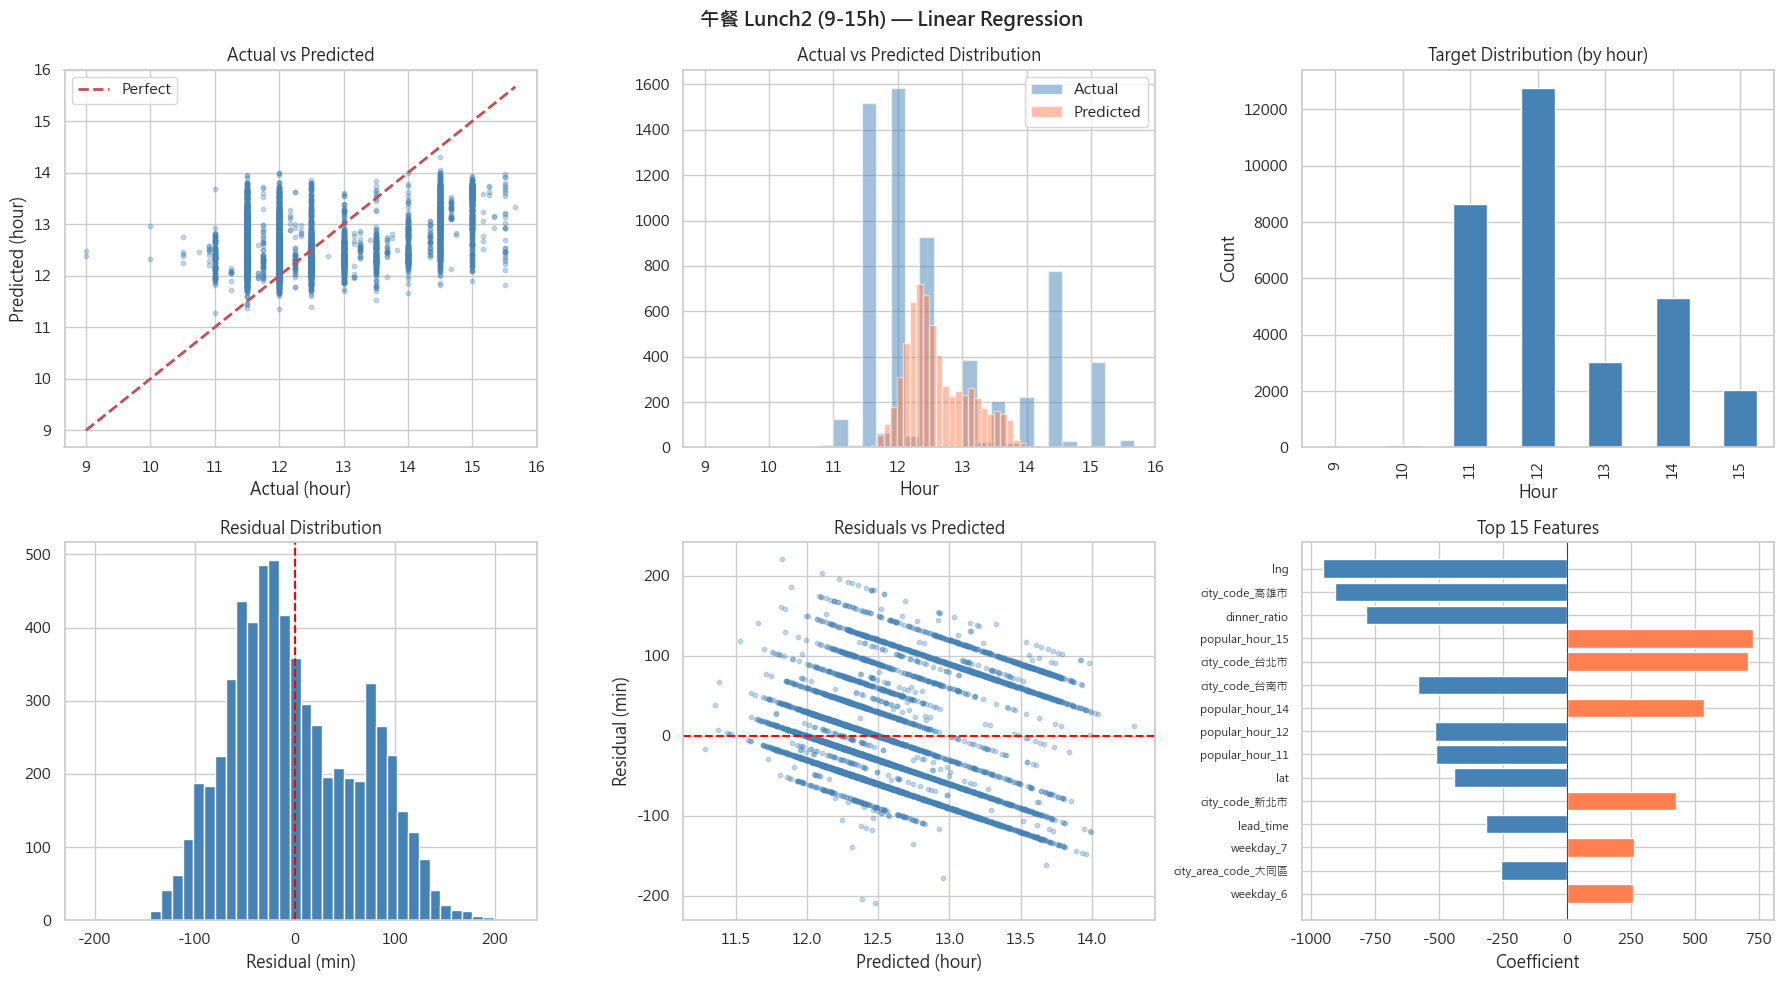


  晚餐 Dinner2 (15-23h)
  Samples : 36,431  (Train 29,144 / Test 7,287)
  Features: 152
  RMSE : 3,754 sec  (62.6 min)
  MAE  : 2,823 sec  (47.0 min)
  R²   : 0.2457


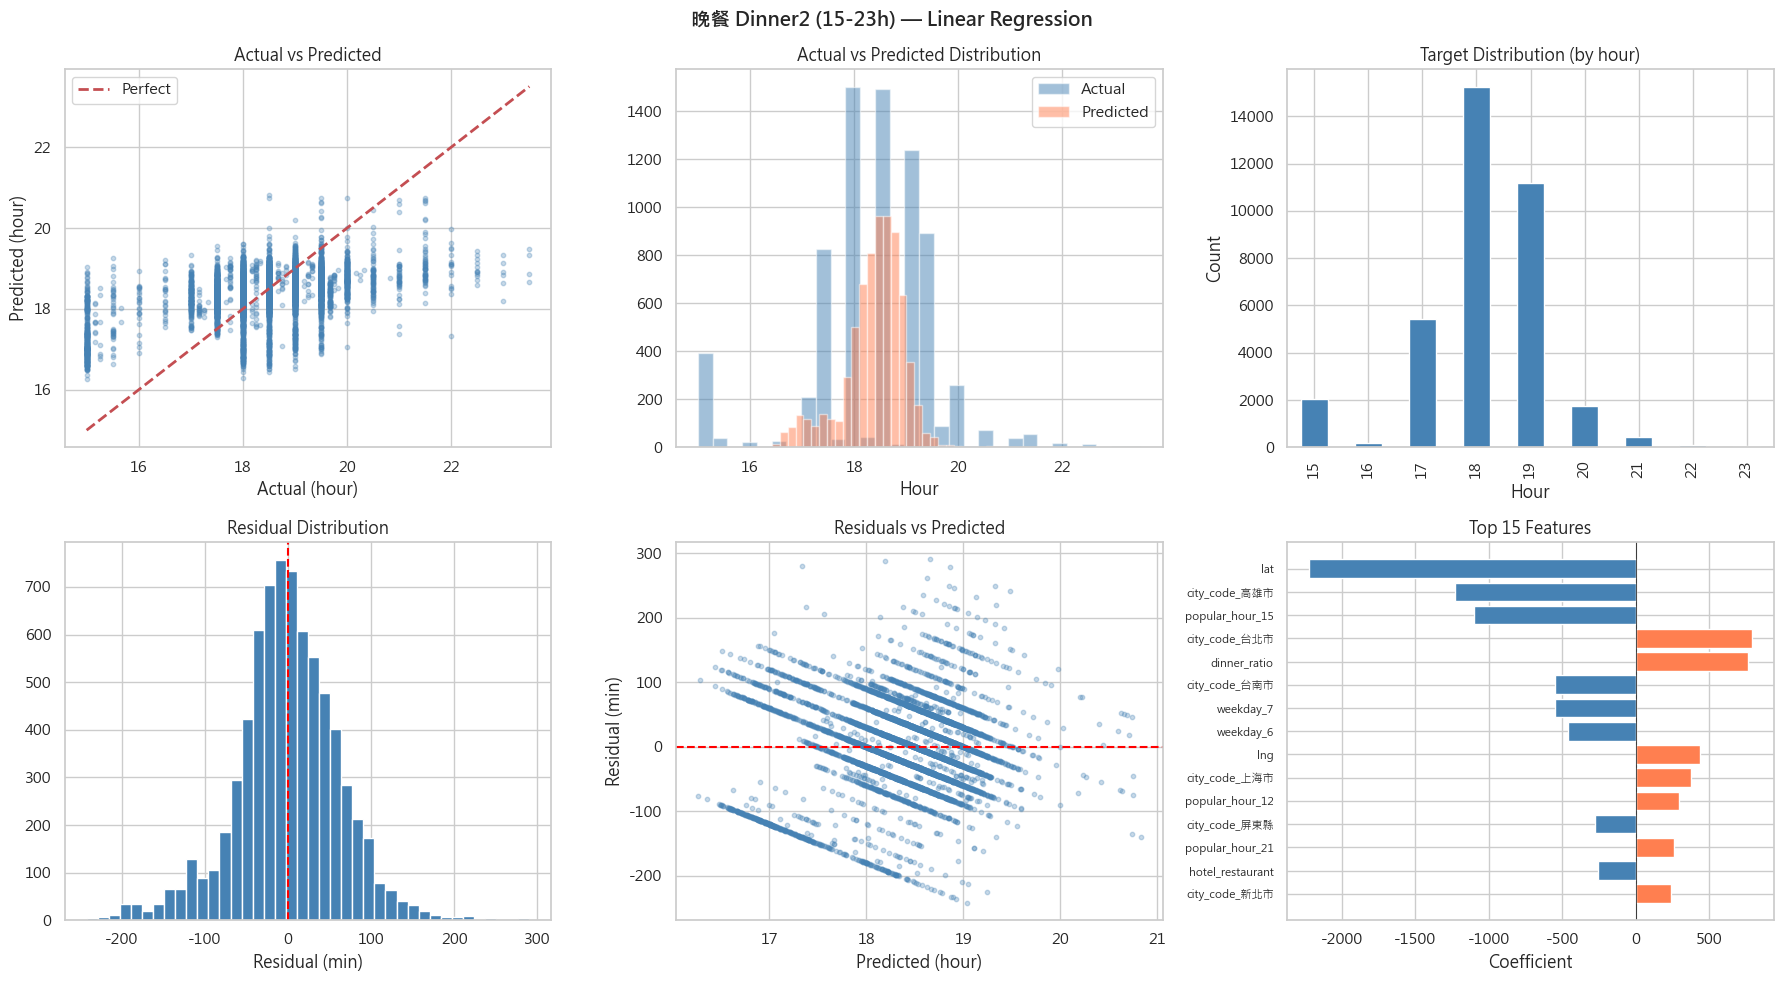

In [23]:
# --- Run analysis (二分法) ---
results2 = []
for subset, label in [
    (df_lunch2,  "午餐 Lunch2 (9-15h)"),
    (df_dinner2, "晚餐 Dinner2 (15-23h)"),
]:
    results2.append(run_subset_analysis(subset, label))

  COMPARISON SUMMARY — 二分法 (vs Full Dataset)


'             Subset  Samples  RMSE (min)  MAE (min)       R²\n    全部 Full Dataset    66349  177.808735 159.843132 0.116691\n  午餐 Lunch2 (9-15h)    31892   64.992170  53.821291 0.168938\n晚餐 Dinner2 (15-23h)    36431   62.569030  47.045196 0.245724'

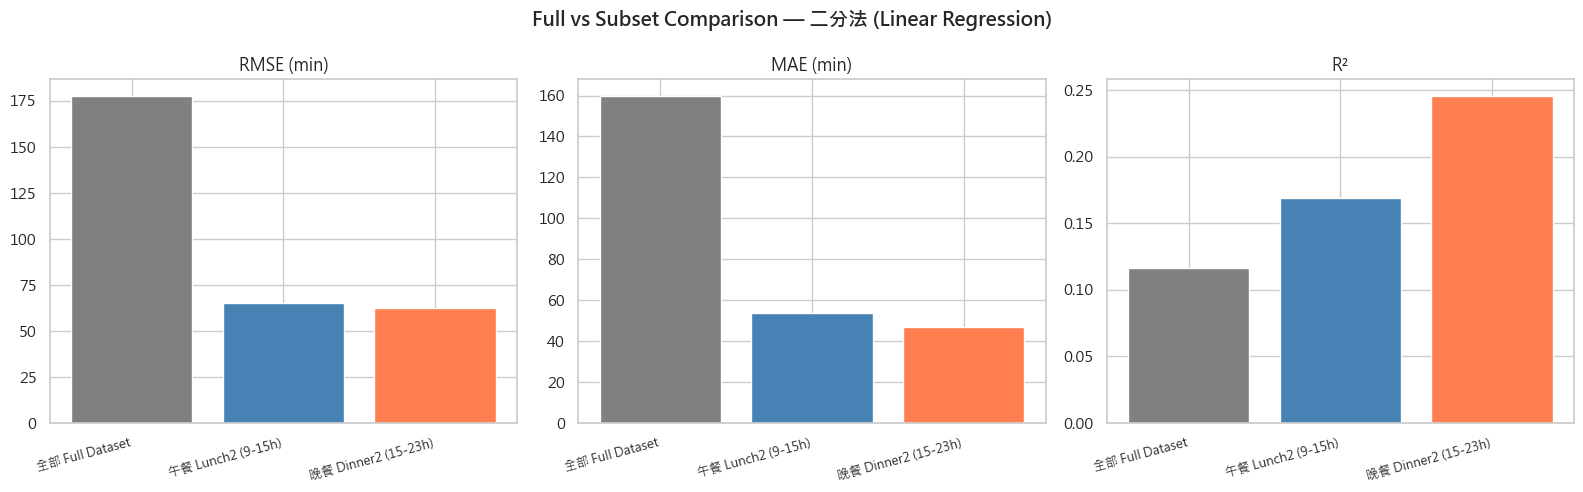

In [24]:
# ============================================================
#  Comparison Summary (二分法 vs Full Dataset)
# ============================================================
print("="*70)
print("  COMPARISON SUMMARY — 二分法 (vs Full Dataset)")
print("="*70)

full_result2 = {
    "label": "全部 Full Dataset",
    "n": len(df),
    "rmse_sec": np.sqrt(mean_squared_error(y_test, y_pred)),
    "mae_sec": mean_absolute_error(y_test, y_pred),
    "r2": r2_score(y_test, y_pred),
}
all_results2 = [full_result2] + results2

comp_df2 = pd.DataFrame(all_results2)
comp_df2["RMSE (min)"] = comp_df2["rmse_sec"] / 60
comp_df2["MAE (min)"]  = comp_df2["mae_sec"] / 60
display(comp_df2[["label", "n", "RMSE (min)", "MAE (min)", "r2"]].rename(columns={
    "label": "Subset", "n": "Samples", "r2": "R²"
}).to_string(index=False))

# Comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_short2 = [r["label"] for r in all_results2]
colors2 = ["gray", "steelblue", "coral"]
x2 = range(len(labels_short2))

for ax, col, title in [
    (axes[0], "RMSE (min)", "RMSE (min)"),
    (axes[1], "MAE (min)",  "MAE (min)"),
    (axes[2], "r2",         "R²"),
]:
    ax.bar(x2, comp_df2[col], color=colors2)
    ax.set_xticks(list(x2))
    ax.set_xticklabels(labels_short2, fontsize=9, rotation=15, ha="right")
    ax.set_title(title)

plt.suptitle("Full vs Subset Comparison — 二分法 (Linear Regression)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Half-Hour Granularity Analysis (半小時顆粒度)

將預測目標改為 `reservation_half_hour`（0-47 的半小時時段），以更細的時間解析度進行 Linear Regression。

**Target**: `reservation_half_hour` (0-47)
**Leakage**: `reservation_hour`, `reservation_seconds`（皆由同一 datetime 衍生）

In [ ]:
# --- Half-Hour: Data Reload ---
df_hh = load_features("../data/processed/features_ready.csv")
df_hh = df_hh.dropna()

# Target distribution
fig, ax = plt.subplots(figsize=(16, 4))
slot_counts = df_hh["reservation_half_hour"].value_counts().sort_index()
slot_labels = [f"{s // 2}:{(s % 2) * 30:02d}" for s in slot_counts.index]
ax.bar(range(len(slot_counts)), slot_counts.values, color="steelblue")
ax.set_xticks(range(len(slot_counts)))
ax.set_xticklabels(slot_labels, rotation=45, ha="right", fontsize=8)
ax.set_title("Reservation Half-Hour Slot Distribution")
ax.set_xlabel("Half-Hour Slot")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

print(f"Shape: {df_hh.shape}")
print(f"Unique slots: {sorted(df_hh['reservation_half_hour'].unique())}")

In [ ]:
# --- Half-Hour: Preprocessing & Training ---
TARGET_HH = "reservation_half_hour"
LEAKAGE_HH = ["reservation_hour", "reservation_seconds"]

df_hh_clean = df_hh.drop(columns=LEAKAGE_HH)
X_train_hh, X_test_hh, y_train_hh, y_test_hh = split_data(df_hh_clean, target_col=TARGET_HH)
X_train_hh_proc, X_test_hh_proc, scaler_hh = preprocess_for_regression(X_train_hh, X_test_hh)

model_hh = LinearRegression()
model_hh.fit(X_train_hh_proc, y_train_hh)
y_pred_hh = model_hh.predict(X_test_hh_proc)

rmse_hh = np.sqrt(mean_squared_error(y_test_hh, y_pred_hh))
mae_hh = mean_absolute_error(y_test_hh, y_pred_hh)
r2_hh = r2_score(y_test_hh, y_pred_hh)

print("=== Linear Regression Half-Hour Performance ===")
print(f"RMSE : {rmse_hh:.2f} slots ({rmse_hh * 30:.0f} min)")
print(f"MAE  : {mae_hh:.2f} slots ({mae_hh * 30:.0f} min)")
print(f"R²   : {r2_hh:.4f}")
print(f"\nInterpretation: 平均預測誤差約 {mae_hh:.1f} 個半小時時段 ({mae_hh * 30:.0f} 分鐘)")

In [ ]:
# --- Half-Hour: Plots ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Linear Regression — Half-Hour Granularity (Full Dataset)", fontsize=14, fontweight="bold")

# (0,0) Actual vs Predicted (convert to H:MM scale)
axes[0, 0].scatter(y_test_hh / 2, y_pred_hh / 2, alpha=0.3, s=10, color="steelblue")
lo, hi = y_test_hh.min() / 2, y_test_hh.max() / 2
axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect")
axes[0, 0].set_xlabel("Actual (hour)")
axes[0, 0].set_ylabel("Predicted (hour)")
axes[0, 0].set_title("Actual vs Predicted")
axes[0, 0].legend()

# (0,1) Distribution comparison
axes[0, 1].hist(y_test_hh, bins=range(0, 49), alpha=0.5, label="Actual", color="steelblue", edgecolor="white", align="left")
axes[0, 1].hist(y_pred_hh, bins=48, alpha=0.5, label="Predicted", color="coral", edgecolor="white")
axes[0, 1].set_xlabel("Half-Hour Slot")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution: Actual vs Predicted")
axes[0, 1].legend()

# (1,0) Residual distribution (in minutes)
residuals_min_hh = (y_test_hh - y_pred_hh) * 30
axes[1, 0].hist(residuals_min_hh, bins=50, color="steelblue", edgecolor="white")
axes[1, 0].axvline(0, color="red", linestyle="--")
axes[1, 0].set_xlabel("Residual (minutes)")
axes[1, 0].set_ylabel("Count")
axes[1, 0].set_title("Residual Distribution")

# (1,1) Feature importance top 20
coef_hh = pd.DataFrame({
    "feature": X_train_hh_proc.columns,
    "coefficient": model_hh.coef_
}).sort_values("coefficient", key=abs, ascending=False)
top_hh = coef_hh.head(20)
bar_colors = ["coral" if c > 0 else "steelblue" for c in top_hh["coefficient"]]
axes[1, 1].barh(range(len(top_hh)), top_hh["coefficient"], color=bar_colors)
axes[1, 1].set_yticks(range(len(top_hh)))
axes[1, 1].set_yticklabels(top_hh["feature"], fontsize=8)
axes[1, 1].invert_yaxis()
axes[1, 1].set_xlabel("Coefficient")
axes[1, 1].set_title("Top 20 Feature Coefficients")
axes[1, 1].axvline(0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
def run_subset_analysis_hh(df_subset, label):
    """對子資料集執行半小時顆粒度的 Linear Regression 分析。"""
    TARGET_HH = "reservation_half_hour"
    LEAKAGE_HH = ["reservation_hour", "reservation_seconds"]

    df_clean = df_subset.drop(columns=LEAKAGE_HH, errors="ignore")
    X_tr, X_te, y_tr, y_te = split_data(df_clean, target_col=TARGET_HH)
    X_tr_proc, X_te_proc, _ = preprocess_for_regression(X_tr, X_te)

    mdl = LinearRegression()
    mdl.fit(X_tr_proc, y_tr)
    y_pr = mdl.predict(X_te_proc)

    rmse = np.sqrt(mean_squared_error(y_te, y_pr))
    mae  = mean_absolute_error(y_te, y_pr)
    r2   = r2_score(y_te, y_pr)

    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    print(f"  Samples : {len(df_subset):,}  (Train {len(X_tr):,} / Test {len(X_te):,})")
    print(f"  RMSE : {rmse:.2f} slots  ({rmse * 30:.0f} min)")
    print(f"  MAE  : {mae:.2f} slots  ({mae * 30:.0f} min)")
    print(f"  R²   : {r2:.4f}")

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"{label} — Linear Regression (Half-Hour)", fontsize=14, fontweight="bold")

    # (0,0) Actual vs Predicted
    axes[0, 0].scatter(y_te / 2, y_pr / 2, alpha=0.3, s=10, color="steelblue")
    lo, hi = y_te.min() / 2, y_te.max() / 2
    axes[0, 0].plot([lo, hi], [lo, hi], "r--", lw=2, label="Perfect")
    axes[0, 0].set_xlabel("Actual (hour)")
    axes[0, 0].set_ylabel("Predicted (hour)")
    axes[0, 0].set_title("Actual vs Predicted")
    axes[0, 0].legend()

    # (0,1) Distribution comparison
    axes[0, 1].hist(y_te, bins=range(int(y_te.min()), int(y_te.max())+2), alpha=0.5,
                    label="Actual", color="steelblue", edgecolor="white", align="left")
    axes[0, 1].hist(y_pr, bins=30, alpha=0.5, label="Predicted", color="coral", edgecolor="white")
    axes[0, 1].set_xlabel("Half-Hour Slot")
    axes[0, 1].set_title("Actual vs Predicted Distribution")
    axes[0, 1].legend()

    # (0,2) Target distribution
    df_subset["reservation_half_hour"].value_counts().sort_index().plot(
        kind="bar", ax=axes[0, 2], color="steelblue")
    axes[0, 2].set_title("Target Distribution")
    axes[0, 2].set_xlabel("Half-Hour Slot")

    # (1,0) Residual distribution
    residuals_min = (y_te - y_pr) * 30
    axes[1, 0].hist(residuals_min, bins=40, color="steelblue", edgecolor="white")
    axes[1, 0].axvline(0, color="red", linestyle="--")
    axes[1, 0].set_xlabel("Residual (min)")
    axes[1, 0].set_title("Residual Distribution")

    # (1,1) Residuals vs Predicted
    axes[1, 1].scatter(y_pr / 2, residuals_min, alpha=0.3, s=10, color="steelblue")
    axes[1, 1].axhline(0, color="red", linestyle="--")
    axes[1, 1].set_xlabel("Predicted (hour)")
    axes[1, 1].set_ylabel("Residual (min)")
    axes[1, 1].set_title("Residuals vs Predicted")

    # (1,2) Feature importance
    coef_df = pd.DataFrame({
        "feature": X_tr_proc.columns,
        "coefficient": mdl.coef_
    }).sort_values("coefficient", key=abs, ascending=False)
    top = coef_df.head(15)
    bar_colors = ["coral" if c > 0 else "steelblue" for c in top["coefficient"]]
    axes[1, 2].barh(range(len(top)), top["coefficient"], color=bar_colors)
    axes[1, 2].set_yticks(range(len(top)))
    axes[1, 2].set_yticklabels(top["feature"], fontsize=8)
    axes[1, 2].invert_yaxis()
    axes[1, 2].set_xlabel("Coefficient")
    axes[1, 2].set_title("Top 15 Features")
    axes[1, 2].axvline(0, color="black", linewidth=0.5)

    plt.tight_layout()
    plt.show()

    return {"label": label, "n": len(df_subset), "rmse_slots": rmse, "mae_slots": mae, "r2": r2}

# --- Split & Run (三分法) ---
df_hh_lunch = df_hh[df_hh["reservation_hour"].between(11, 14)]
df_hh_afternoon = df_hh[df_hh["reservation_hour"].between(15, 17)]
df_hh_dinner = df_hh[df_hh["reservation_hour"].between(18, 23)]

print(f"午餐 Lunch      (11-14h): {len(df_hh_lunch):>6,} rows")
print(f"下午茶 Afternoon (15-17h): {len(df_hh_afternoon):>6,} rows")
print(f"晚餐 Dinner     (18-23h): {len(df_hh_dinner):>6,} rows")

results_hh = []
for subset, label in [
    (df_hh_lunch,     "午餐 Lunch (11-14h)"),
    (df_hh_afternoon, "下午茶 Afternoon Tea (15-17h)"),
    (df_hh_dinner,    "晚餐 Dinner (18-23h)"),
]:
    results_hh.append(run_subset_analysis_hh(subset, label))

In [ ]:
# ============================================================
#  Comparison Summary — Half-Hour (vs Full Dataset)
# ============================================================
print("="*70)
print("  COMPARISON SUMMARY — Half-Hour Granularity (vs Full Dataset)")
print("="*70)

full_result_hh = {
    "label": "全部 Full Dataset",
    "n": len(df_hh),
    "rmse_slots": rmse_hh,
    "mae_slots": mae_hh,
    "r2": r2_hh,
}
all_results_hh = [full_result_hh] + results_hh

comp_df_hh = pd.DataFrame(all_results_hh)
comp_df_hh["RMSE (min)"] = comp_df_hh["rmse_slots"] * 30
comp_df_hh["MAE (min)"]  = comp_df_hh["mae_slots"] * 30
display(comp_df_hh[["label", "n", "RMSE (min)", "MAE (min)", "r2"]].rename(columns={
    "label": "Subset", "n": "Samples", "r2": "R²"
}).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels_hh = [r["label"] for r in all_results_hh]
colors_hh = ["gray", "steelblue", "coral", "seagreen"]
x_hh = range(len(labels_hh))

for ax, col, title in [
    (axes[0], "RMSE (min)", "RMSE (min)"),
    (axes[1], "MAE (min)",  "MAE (min)"),
    (axes[2], "r2",         "R²"),
]:
    ax.bar(x_hh, comp_df_hh[col], color=colors_hh)
    ax.set_xticks(list(x_hh))
    ax.set_xticklabels(labels_hh, fontsize=9, rotation=15, ha="right")
    ax.set_title(title)

plt.suptitle("Full vs Subset — Half-Hour (Linear Regression)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()